We set a seed for reproducibility across different runs.

In [1]:
SEED = 158

We install the necessary Python libraries and their dependencies.

In [2]:
!pip install -q -U "transformers>=4.52.0"
!pip install "accelerate>=0.31.0" bitsandbytes datasets evaluate scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.2 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatibl

We import all the required libraries for the project, define a `seed_everything` function to ensure reproducibility, and set global constants like `MODEL_NAME`, `MAX_NEW_TOKENS_AGENT` ,`MAX_NEW_TOKENS_DECISION` , and column names (`question_col`, `answer_col`).

In [3]:
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

import warnings
# So that it does not show all the warnings but the errors only
warnings.filterwarnings("ignore")

from transformers import logging

logging.set_verbosity_error()

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)

LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
MODEL_NAME = "Qwen/Qwen3.5-0.8B"
MAX_NEW_TOKENS_AGENT = 256
MAX_NEW_TOKENS_DECISION = 128

question_col = "question"
answer_col = "answer"

We load the `AutoTokenizer` and `AutoModelForCausalLM` from the `MODEL_NAME`. It configures the model and creates a HuggingFace `pipeline` for text generation.

In [4]:
print(f"Loading tokenizer and model for: {MODEL_NAME}")

def load_qwen_model(model_name=MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer, model

qwen_tokenizer, qwen_model = load_qwen_model(MODEL_NAME)
print("Loaded", MODEL_NAME)

tokenizer = qwen_tokenizer

chat_pipeline = pipeline(
    "text-generation",
    model=qwen_model,
    tokenizer=qwen_tokenizer,
)

Loading tokenizer and model for: Qwen/Qwen3.5-0.8B


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-0.8B


This cell loads the dataset using the `datasets` library. It then converts the 'train' and 'test' splits into pandas DataFrames and renames specified columns.

In [5]:
from datasets import load_dataset

DATASET_NAME = "ailsntua/QEvasion"

dataset = load_dataset(DATASET_NAME)
print(dataset)

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas() if "test" in dataset else None

print("Original train shape:", train_df.shape)
if test_df is not None:
    print("Original test shape:", test_df.shape)

# Simple column rename
COLUMN_RENAME = {
    "question": "question",
    "interview_answer": "answer",
    "clarity_label": "label",
    "index": "id",
}

train_df = train_df.rename(columns=COLUMN_RENAME)
if test_df is not None:
    test_df = test_df.rename(columns=COLUMN_RENAME)

print("\nAfter renaming:")
print("train columns:", train_df.columns.tolist())
if test_df is not None:
    print("test columns:", test_df.columns.tolist())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})
Original train shape: (3448, 20)
Original test shape: (308, 20)

After renaming:
train columns: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'q

The following functions:
- generate_chat(): Generates a response from the model using a chat template.
- extract_json_object(): Extracts the first valid JSON object from the model's output.
- normalize_prediction_label(): Standardizes prediction labels to match the official CLARITY dataset classes ('Clear Reply', 'Clear Non-Reply', 'Ambivalent').

In [6]:
def extract_json_object(text):
    if text is None:
        return {"raw": ""}
    text = text.strip()
    text = re.sub(r"^```(?:json)?", "", text, flags=re.IGNORECASE).strip()
    text = re.sub(r"```$", "", text).strip()
    try:
        obj = json.loads(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        try:
            obj = json.loads(match.group(0))
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass
    return {"raw": text}

def normalize_label(text):
    """Map raw model output to one of the three canonical labels."""
    s = str(text).strip()
    key = re.sub(r"\s+", " ", s.lower().replace("_", " ")).strip()
    if "non" in key and "reply" in key:
        return "Clear Non-Reply"
    if "ambivalent" in key or "ambiguous" in key or "partial" in key or "unclear" in key:
        return "Ambivalent"
    if "clear reply" in key or key == "reply":
        return "Clear Reply"
    return ""

def normalize_prediction_label(text):
    if text is None:
        return "Ambivalent"
    s = str(text).strip()
    normalized = normalize_label(s)
    if normalized in LABELS:
        return normalized
    key = re.sub(r"\s+", " ", s.lower().replace("_", " ")).strip()
    if "non" in key and "reply" in key:
        return "Clear Non-Reply"
    if "ambivalent" in key or "ambiguous" in key or "partial" in key or "unclear" in key:
        return "Ambivalent"
    if "clear reply" in key:
        return "Clear Reply"
    for label in LABELS:
        if label.lower() in key:
            return label
    return "Ambivalent"

def messages_to_prompt(messages):
    if hasattr(qwen_tokenizer, "apply_chat_template"):
        return qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    rendered = ""
    for m in messages:
        rendered += f"{m['role'].upper()}:\n{m['content']}\n\n"
    return rendered + "ASSISTANT:\n"

@torch.inference_mode()
def generate_chat(messages, max_new_tokens=160):
    prompt = messages_to_prompt(messages)
    inputs = qwen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4096)
    inputs = {k: v.to(qwen_model.device) for k, v in inputs.items()}
    output_ids = qwen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=None,
        top_p=None,
        pad_token_id=qwen_tokenizer.pad_token_id,
        eos_token_id=qwen_tokenizer.eos_token_id,
    )
    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    return qwen_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

We normalize the 'label' column in the `train_df` using the `normalize_prediction_label` function. It then splits the `train_df` into training `train_part` and validation `valid_df` sets.

In [7]:
train_part, valid_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"],
)
train_part = train_part.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(f"Train subset size: {train_part.shape[0]} | Validation subset size: {valid_df.shape[0]}")
print(valid_df["label"].value_counts())

Train subset size: 2758 | Validation subset size: 690
label
Ambivalent         408
Clear Reply        211
Clear Non-Reply     71
Name: count, dtype: int64


The following functions:
- valuate_predictions() : Calculates accuracy and F1 scores (macro and per-class) and stores them.
- print_full_report() : Prints a detailed report.
- plot_confusion_matrix() : Generates and displays a confusion matrix plot.

In [8]:
all_results = []

def evaluate_predictions(y_true, y_pred, model_name_str):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    prec, rec, f1_cls, _ = precision_recall_fscore_support(y_true, y_pred, labels=["Clear Reply", "Ambivalent", "Clear Non-Reply"])
    
    res = {
        "model": model_name_str,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_clear_reply": f1_cls[0],
        "f1_ambivalent": f1_cls[1],
        "f1_clear_non_reply": f1_cls[2]
    }
    return res

def print_full_report(y_true, y_pred, title):
    print(f"\n REPORT FOR: {title}")
    print(classification_report(y_true, y_pred, digits=4))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=["Clear Reply", "Ambivalent", "Clear Non-Reply"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Clear Reply", "Ambivalent", "Clear Non-Reply"])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

We define the system prompts for the agents involved:
1. Question Intent Agent: Gets requirements from a question.
2. Answer Content Agent: Gets claims and semantic information from an answer.
3. Gap and Evasion Agent: Compares question intent with answer content to watch out for gaps and evasions.
4. Decision Agent: Classifies response clarity into 'Clear Reply', 'Ambivalent', or 'Clear Non-Reply'.

In [9]:
QUESTION_INTENT_PROMPT = """
You are the Question Intent Agent for a response-clarity classification task.

Important dataset rule:
The TARGET_QUESTION may be only one sub-question extracted from a longer interview question.
Analyze ONLY the TARGET_QUESTION. Do not require the answer to address other questions unless they are necessary for this target question.

Your task:
Identify exactly what information would make an answer clear for the TARGET_QUESTION.

Think in terms of answer requirements:
- Is the question asking for yes/no?
- Is it asking what happened?
- Is it asking why/how something happened?
- Is it asking for a specific action, plan, reason, explanation, stance, or evaluation?
- Is it asking about a named person, event, country, policy, organization, or date?

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_type": "yes_no|what|why|how|when|where|who|stance|explanation|action_plan|evaluation|other",
  "question_intent": "one sentence describing what the target question asks",
  "must_address": [
    "specific requirement 1",
    "specific requirement 2"
  ],
  "clear_answer_criteria": "one sentence describing what a clear answer must contain",
  "minimal_sufficient_answer": "short description of the minimum information needed for Clear Reply"
}
""".strip()

In [10]:
def run_question_intent_agent(question):
    messages = [
        {"role": "system", "content": QUESTION_INTENT_PROMPT},
        {"role": "user", "content": f"Question:\n{question}"},
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_AGENT
    )

    obj = extract_json_object(raw)
    obj["raw"] = raw
    return obj

In [11]:
ANSWER_CONTENT_PROMPT = """
You are the Answer Content Agent for a response-clarity classification task.

Important dataset rule:
The answer may respond to a longer interview question, but you must evaluate what it says with respect to the TARGET_QUESTION only.

Your task:
Extract what the answer actually says that is relevant to the TARGET_QUESTION.

Do not decide the final label.
Do not reward political rhetoric unless it answers the target question.
Do not infer facts that are not present in the answer.
An implicit answer is allowed only if the answer gives enough information to resolve the target question.

Look for:
- direct answer phrases: yes, no, I did, I did not, we will, we will not, because...
- concrete facts, actions, reasons, explanations, examples, commitments
- vague but related statements
- topic shifts
- refusals or declines to answer
- answers to a different sub-question

Return exactly one JSON object and nothing else.

JSON schema:
{
  "relevant_answer_summary": "one sentence summarizing only content relevant to the target question",
  "direct_answer_present": true,
  "direct_answer_text": "exact short phrase if present, otherwise empty string",
  "concrete_information": [
    "concrete relevant point 1",
    "concrete relevant point 2"
  ],
  "vague_or_general_information": [
    "vague/general relevant point 1"
  ],
  "off_target_content": [
    "content that answers a different question or changes topic"
  ],
  "refusal_or_non_answer_signals": [
    "signal 1"
  ]
}
""".strip()


GAP_EVASION_PROMPT = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. the Question Intent Agent output,
4. the Answer Content Agent output.

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "missing requirement 1"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()


DECISION_PROMPT = """
You are the Decision Agent for CLARITY response classification.

Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:

Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.

Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.

Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- If coverage is complete or mostly_complete and the answer resolves the target question -> Clear Reply.
- If coverage is partial/minimal but there is relevant information -> Ambivalent.
- If coverage is none, or the response is mainly refusal/deflection/irrelevant -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Few-shot calibration examples:

Example A:
Target question: "Did you support the bill?"
Answer content: "Yes, I voted for it and I still support it."
Gap analysis: coverage complete; explicit answer.
Final label: Clear Reply.

Example B:
Target question: "What specific steps will you take to reduce prices?"
Answer content: "Families are struggling, this is important, and we are working every day."
Gap analysis: relevant but no specific steps.
Final label: Ambivalent.

Example C:
Target question: "Did you meet with the ambassador?"
Answer content: "I am not going to discuss private diplomatic conversations."
Gap analysis: declining to answer; no requested information.
Final label: Clear Non-Reply.

Example D:
Target question: "Why did unemployment increase?"
Answer content: "The economy has faced global pressure, energy shocks, and reduced demand."
Gap analysis: gives reasons even without saying 'because'.
Final label: Clear Reply.

Example E:
Target question: "Do you think President X is sincere?"
Answer content: "I am sincere about improving the relationship."
Gap analysis: answers the speaker's sincerity, not President X's sincerity.
Final label: Ambivalent.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

We implement the functions to run each of the four agents (Question Intent, Answer Content, Gap & Evasion, Decision) by constructing messages for the `generate_chat` function and extracting JSON outputs.

In [12]:
def run_answer_content_agent(question, answer):
    messages = [
        {"role": "system", "content": ANSWER_CONTENT_PROMPT},
        {
            "role": "user",
            "content": f"Question:\n{question}\n\nAnswer:\n{answer}",
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_AGENT
    )

    obj = extract_json_object(raw)
    obj["raw"] = raw
    return obj


def run_gap_evasion_agent(question, answer, question_intent, answer_content):
    user_payload = {
        "question": question,
        "answer": answer,
        "question_intent_agent_output": question_intent,
        "answer_content_agent_output": answer_content,
    }

    messages = [
        {"role": "system", "content": GAP_EVASION_PROMPT},
        {
            "role": "user",
            "content": json.dumps(user_payload, ensure_ascii=False, indent=2),
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_AGENT
    )

    obj = extract_json_object(raw)
    obj["raw"] = raw
    return obj


def run_decision_agent(question, answer, question_intent, answer_content, gap_evasion):
    user_payload = {
        "question": question,
        "answer": answer,
        "question_intent_agent_output": question_intent,
        "answer_content_agent_output": answer_content,
        "gap_and_evasion_agent_output": gap_evasion,
    }

    messages = [
        {"role": "system", "content": DECISION_PROMPT},
        {
            "role": "user",
            "content": json.dumps(user_payload, ensure_ascii=False, indent=2),
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_DECISION
    )

    obj = extract_json_object(raw)

    label = normalize_prediction_label(
        obj.get("label", raw)
    )

    return {
        "label": label,
        "confidence": obj.get("confidence", None),
        "rationale": obj.get("rationale", ""),
        "raw": raw,
    }

The following functions:
- run_d3_one() : Executes the full D3 pipeline for a single question-answer pair.
- run_d3_dataframe() : Processes an entire DataFrame of question-answer pairs, running the D3 pipeline for each and returning a DataFrame with all results.

In [13]:
def run_d3_one(question, answer):
    question_intent = run_question_intent_agent(question)
    answer_content = run_answer_content_agent(question, answer)
    gap_evasion = run_gap_evasion_agent(question, answer, question_intent, answer_content)
    decision = run_decision_agent(question, answer, question_intent, answer_content, gap_evasion)
    
    return {
        "d3_question_intent": json.dumps(question_intent, ensure_ascii=False),
        "d3_answer_content": json.dumps(answer_content, ensure_ascii=False),
        "d3_gap_evasion": json.dumps(gap_evasion, ensure_ascii=False),
        "d3_decision": json.dumps(decision, ensure_ascii=False),
        "pred_d3": decision["label"],
        "d3_confidence": decision.get("confidence", None),
        "d3_rationale": decision.get("rationale", ""),
    }

def run_d3_dataframe(df, output_path, limit=None, checkpoint_every=25):
    run_df = df.copy()
    if limit is not None:
        run_df = run_df.head(limit).copy()
        
    rows = []
    for i, row in tqdm(run_df.iterrows(), total=len(run_df), desc="D3-Agentic Prompting"):
        try:
            out = run_d3_one(str(row[question_col]), str(row[answer_col]))
        except Exception as e:
            out = {
                "d3_question_intent": "",
                "d3_answer_content": "",
                "d3_gap_evasion": "",
                "d3_decision": json.dumps({"error": str(e)}, ensure_ascii=False),
                "pred_d3": "Ambivalent",
                "d3_confidence": None,
                "d3_rationale": f"Fallback after error: {e}",
            }
        rows.append(out)
        
        if len(rows) % checkpoint_every == 0:
            checkpoint_df = pd.concat([
                run_df.iloc[:len(rows)].reset_index(drop=True),
                pd.DataFrame(rows),
            ], axis=1)
            checkpoint_df.to_csv(output_path, index=False)
            print(f"Checkpoint saved: {output_path} | rows={len(rows)}")
            
    result_df = pd.concat([
        run_df.reset_index(drop=True),
        pd.DataFrame(rows),
    ], axis=1)
    result_df.to_csv(output_path, index=False)
    print("Saved final outputs to:", output_path)
    return result_df

We create a working directory, set a limit for validation, run the `run_d3_dataframe` function, and then evaluate the predictions using `evaluate_predictions`, `print_full_report`, and `plot_confusion_matrix`.

Running D3 Validation Loop...


D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

Checkpoint saved: content/d3_validation_outputs.csv | rows=25
Checkpoint saved: content/d3_validation_outputs.csv | rows=50
Checkpoint saved: content/d3_validation_outputs.csv | rows=75
Checkpoint saved: content/d3_validation_outputs.csv | rows=100
Saved final outputs to: content/d3_validation_outputs.csv

 REPORT FOR: D3-Agentic Prompting: Qwen/Qwen3.5-0.8B
                 precision    recall  f1-score   support

     Ambivalent     0.5714    0.6792    0.6207        53
Clear Non-Reply     0.2000    0.1000    0.1333        10
    Clear Reply     0.5312    0.4595    0.4928        37

       accuracy                         0.5400       100
      macro avg     0.4342    0.4129    0.4156       100
   weighted avg     0.5194    0.5400    0.5246       100



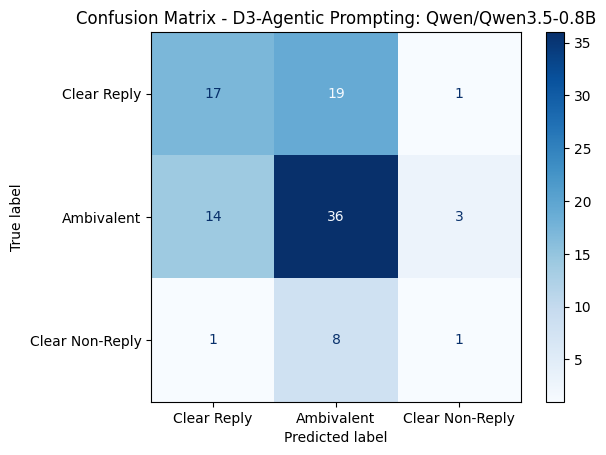

,model,accuracy,f1_macro,f1_clear_reply,f1_ambivalent,f1_clear_non_reply
0,D3-Agentic Prompting: Qwen/Qwen3.5-0.8B,0.54,0.415592,0.492754,0.62069,0.133333


In [14]:
WORK_DIR = Path("./content")
WORK_DIR.mkdir(parents=True, exist_ok=True)

D3_VALID_LIMIT = 100 
d3_valid_path = WORK_DIR / "d3_validation_outputs.csv"

print("Running D3 Validation Loop...")
d3_valid_df = run_d3_dataframe(
    valid_df,
    output_path=d3_valid_path,
    limit=D3_VALID_LIMIT,
    checkpoint_every=25,
)

d3_y_true = d3_valid_df["label"].tolist()
d3_y_pred = d3_valid_df["pred_d3"].tolist()

d3_result = evaluate_predictions(d3_y_true, d3_y_pred, f"D3-Agentic Prompting: {MODEL_NAME}")
all_results.append(d3_result)

print_full_report(d3_y_true, d3_y_pred, f"D3-Agentic Prompting: {MODEL_NAME}")
plot_confusion_matrix(d3_y_true, d3_y_pred, f"D3-Agentic Prompting: {MODEL_NAME}")

results_df = pd.DataFrame(all_results)
display(results_df)

We run the D3 on the `test_df` to generate predictions for submission. We call `run_d3_dataframe` without a limit, create a `submission.csv`.

In [15]:
d3_test_path = WORK_DIR / "d3_test_outputs.csv"

print("Running D3 on Test Set...")

d3_test_df = run_d3_dataframe(
    test_df,
    output_path=d3_test_path,
    limit=None,
    checkpoint_every=50
)

submission = pd.DataFrame({
    "Id": d3_test_df["id"] if "id" in d3_test_df.columns else d3_test_df.index,
    "Predicted": d3_test_df["pred_d3"]
})

submission.to_csv("submission_best_d3_agentic_system.csv", index=False)
submission.to_csv("submission.csv", index=False)

print("Submission completed.")
print('\nFirst 20 rows:')
print(submission.head(20))

Running D3 on Test Set...


D3-Agentic Prompting:   0%|          | 0/308 [00:00<?, ?it/s]

Checkpoint saved: content/d3_test_outputs.csv | rows=50
Checkpoint saved: content/d3_test_outputs.csv | rows=100
Checkpoint saved: content/d3_test_outputs.csv | rows=150
Checkpoint saved: content/d3_test_outputs.csv | rows=200
Checkpoint saved: content/d3_test_outputs.csv | rows=250
Checkpoint saved: content/d3_test_outputs.csv | rows=300
Saved final outputs to: content/d3_test_outputs.csv
Submission completed.

First 20 rows:
    Id    Predicted
0    0   Ambivalent
1    1   Ambivalent
2    2   Ambivalent
3    3  Clear Reply
4    4   Ambivalent
5    5  Clear Reply
6    6   Ambivalent
7    7  Clear Reply
8    8   Ambivalent
9    9   Ambivalent
10  10   Ambivalent
11  11   Ambivalent
12  12   Ambivalent
13  13   Ambivalent
14  14  Clear Reply
15  15   Ambivalent
16  16   Ambivalent
17  17  Clear Reply
18  18  Clear Reply
19  19   Ambivalent
